# Atelier Préparation de Données Tabulaires
## Bâtiments intelligents — capteurs IoT

**Contexte :** une entreprise exploite plusieurs bâtiments intelligents équipés de capteurs IoT.
Chaque capteur collecte des informations sur la température, l'humidité, la qualité de l'air (CO₂),
la consommation énergétique, l'occupation, le type de bâtiment, le mode de climatisation et l'état
du système.

**Objectif :** transformer le fichier brut `smart_building_raw.csv` en un jeu de données propre,
prêt à être utilisé par un algorithme de Machine Learning (prédiction de consommation énergétique
ou détection d'anomalies via la variable `alerte`).

---
# Partie 1 — Explorer les données

<mark style= "background-color: lightblue">**📋Question 1.1** </mark>

 Charger les données CSV

In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("../data/smart_building_raw.csv")

<mark style= "background-color: lightblue">**📋Question 1.2** </mark>

Afficher les preméres lignes du dataset


In [6]:
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


<mark style= "background-color: lightblue">**📋Question 1.3** </mark>

Afficher les derniéres lignes du dataset

In [7]:
df.tail()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


<mark style= "background-color: lightblue">**📋Question 1.4** </mark>

Combien d'observations contient le dataset ?

In [8]:
num_observations = df.shape[0]
print(f"Nombre d'observations: {num_observations}")

Nombre d'observations: 507


<mark style= "background-color: lightblue">**📋Question 1.5** </mark>

Combien de variables possède le dataset ? 

In [9]:
num_variables = df.shape[1]
print(f"Nombre de variables: {num_variables}")

Nombre de variables: 14


<mark style= "background-color: lightblue">**📋Question 1.6** </mark>

Identifier les variables numériques ; 

Une variable numérique est une variable dont les valeurs sont des quantités mesurables (continues), à distinguer des identifiants qui, bien que numériques, ne représentent pas une quantité.

In [10]:
print("Types de variables:")
print(df.dtypes)

Types de variables:
id_mesure               int64
date                      str
batiment                  str
type_batiment             str
zone                      str
temperature           float64
humidite              float64
co2                   float64
occupation            float64
consommation_kwh      float64
mode_climatisation        str
etat_systeme              str
jour_semaine              str
alerte                    str
dtype: object


In [11]:
variables_num= df.select_dtypes(include=['number']).columns.tolist()
print ("Variables numériques:")
print(variables_num)

Variables numériques:
['id_mesure', 'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']


<mark style= "background-color: lightblue">**📋Question 1.7** </mark>

Identifier les variables catégorielles

In [12]:
variables_cat = df.select_dtypes(include=['object', 'str','category']).columns.tolist()
print("Variables catégorielles:")
print(variables_cat)

Variables catégorielles:
['date', 'batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']


<mark style= "background-color: lightblue">**📋Question 1.8** </mark>

Identifier les dates



Le dataset contient une colonne **"date"** qui doit être exploitée comme telle, mais elle est
chargée par pandas comme une simple chaîne de caractères **(texte)** et non comme une vraie date.

On la convertit donc avec **pd.to_datetime()**, ce qui permettra ensuite de trier les mesures
chronologiquement ou d'en extraire des informations utiles (mois, heure, jour de la semaine...).

Le paramètre **errors="coerce"** indique que si une valeur ne peut pas être interprétée comme une
date valide, elle sera remplacée par **NaT** (Not a Time, l'équivalent de NaN pour les dates) plutôt
que de provoquer une erreur qui arrêterait tout le programme.

On vérifie enfin le type de la colonne après conversion pour confirmer qu'elle est bien passée
en datetime64.

In [13]:
dates = ["date"]
print("Colonne(s) de type date :", dates)

# Conversion au format datetime pour pouvoir l'exploiter (extraction mois/heure, tri, etc.)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
print(df["date"].dtype)

Colonne(s) de type date : ['date']
datetime64[us]


<mark style= "background-color: lightblue">**📋Question 1.9** </mark>

Identifier les identifiants 


In [14]:
identifiant = ["id_mesure"]
print("Colonne(s) identifiant :", identifiant)

Colonne(s) identifiant : ['id_mesure']


<mark style= "background-color: lightblue">**📋Question 1.10** </mark>

Déterminer les statistiques : moyenne, médiane, minimum, maximum, écart-type et quartiles. 

In [15]:
stat_numeriques = df[variables_num].describe().T
stat_numeriques["median"] = df[variables_num].median()
stat_numeriques[["min", "25%", "50%", "median", "75%", "max", "mean", "std"]]



,min,25%,50%,median,75%,max,mean,std
id_mesure,1001.0,1125.500,1252.00,1252.00,1376.500,1500.0,1251.114398,144.782769
temperature,-30.0,21.600,24.00,24.00,26.000,96.0,24.154141,7.418465
humidite,-12.0,49.275,57.55,57.55,65.750,160.0,57.864113,16.026336
co2,89.0,623.750,787.50,787.50,952.000,6000.0,844.150000,582.181386
occupation,-20.0,27.000,46.00,46.00,61.000,116.0,44.850299,24.949139
consommation_kwh,-100.0,136.875,169.80,169.80,202.975,336.2,169.069323,53.164294


<mark style= "background-color: lightblue">**📋Question 1.11** </mark>

Y a-t-il des variables potentiellement problématiques ?

En observant les `min`/`max` ci-dessus :
- **temperature** : min à -30°C, max à 96°C → impossible physiquement.
- **humidite** : min négatif, max à 160% → une humidité relative est comprise entre 0 et 100%.
- **occupation** : valeurs négatives → un nombre de personnes ne peut pas être négatif.
- **consommation_kwh** : valeurs négatives → une consommation ne peut pas être négative.
- **co2** : max à 6000 ppm, élevé mais pas impossible (valeur extrême à surveiller).


<mark style= "background-color: lightblue">**📋Question 1.12-— Données incohérentes** </mark>

 **12.a** : rechercher des valeurs telles que humidité < 0 ;

In [16]:
humidite_neg = df["humidite"] < 0
print(f"{humidite_neg.sum()} valeurs d'humidité négatives :")
df.loc[humidite_neg, ["id_mesure", "humidite"]]

3 valeurs d'humidité négatives :


,id_mesure,humidite
281,1126,-5.0
335,1036,-8.0
366,1216,-12.0


**12.b** Rechercher des valeurs telles que humidité > 100


In [17]:
humidite_sup = df["humidite"] > 100
print(f"{humidite_sup.sum()} valeurs d'humidité supérieures à 0 :")
df.loc[humidite_sup, ["id_mesure", "humidite"]]

7 valeurs d'humidité supérieures à 0 :


,id_mesure,humidite
59,1246,108.0
103,1016,145.0
128,1156,160.0
160,1186,125.0
268,1276,140.0
327,1066,132.0
342,1096,110.0


**12.c** rechercher des valeurs telles que température extrêmement élevée 

> On fixe une plage réaliste pour la température d'un bâtiment, entre -10°C et 50°C, en laissant une marge large pour ne pas écarter des cas extrêmes mais réels — juste assez pour repérer les valeurs clairement impossibles.

In [18]:
temp_aberrante = (df["temperature"] < -10) | (df["temperature"] > 50)
print(f"{temp_aberrante.sum()} valeurs de température incohérentes :")
df.loc[temp_aberrante, ["id_mesure", "temperature"]]

6 valeurs de température incohérentes :


,id_mesure,temperature
7,1141,72.5
116,1181,96.0
161,1061,88.0
185,1221,-25.0
358,1101,-30.0
499,1021,95.2


**12.d** Rechercher des valeurs telles que occupation négative 

In [19]:
occupation_neg = df["occupation"] < 0
print(f"{occupation_neg.sum()} valeurs d'occupation négatives :")
df.loc[occupation_neg, ["id_mesure", "occupation"]]

5 valeurs d'occupation négatives :


,id_mesure,occupation
22,1031,-5.0
376,1231,-8.0
430,1081,-12.0
487,1131,-2.0
494,1331,-20.0


**12.e** rechercher des valeurs telles que consommation négative 

In [20]:
consom_neg = df["consommation_kwh"] < 0
print(f"{consom_neg.sum()} valeurs de consommation négatives :")
df.loc[consom_neg, ["id_mesure", "consommation_kwh"]]

4 valeurs de consommation négatives :


,id_mesure,consommation_kwh
59,1246,-15.0
154,1046,-50.0
199,1146,-20.0
441,1346,-100.0


**12.f**    Si une valeur est manifestement erronée et qu’on ne peut pas retrouver sa vraie valeur, la transformer en valeur manquante 

In [21]:
df.loc[humidite_neg | humidite_sup, "humidite"] = np.nan
df.loc[temp_aberrante, "temperature"] = np.nan
df.loc[occupation_neg, "occupation"] = np.nan
df.loc[consom_neg, "consommation_kwh"] = np.nan

print("Valeurs incohérentes converties en NaN. Nouveau résumé :")
df[variables_num].describe()

Valeurs incohérentes converties en NaN. Nouveau résumé :


,id_mesure,temperature,humidite,co2,occupation,consommation_kwh
count,507.000000,489.000000,486.000000,500.000000,496.000000,498.000000
mean,1251.114398,23.843763,57.213169,844.150000,45.397177,170.798795
std,144.782769,3.254172,12.331736,582.181386,24.460678,49.637307
min,1001.000000,12.300000,21.500000,89.000000,0.000000,26.400000
25%,1125.500000,21.600000,49.350000,623.750000,28.000000,137.675000
50%,1252.000000,24.000000,57.400000,787.500000,46.000000,170.100000
75%,1376.500000,25.900000,65.300000,952.000000,61.000000,204.150000
max,1500.000000,34.200000,90.700000,6000.000000,116.000000,336.200000


**12.g** rechercher des valeurs telles que catégories mal orthographiées

In [22]:
print("type_batiment :")
print(df["type_batiment"].value_counts(dropna=False))
print("\nmode_climatisation :")
print(df["mode_climatisation"].value_counts(dropna=False))

type_batiment :
type_batiment
Bureau               210
Centre commercial     65
École                 59
Hôpital               58
Entrepôt              52
Université            48
NaN                    4
BUREAU                 2
ÉCOLE                  1
ecole                  1
Bureu                  1
bureau                 1
 UNIVERSITÉ            1
hôpital                1
centre commercial      1
 Bureau                1
entrepot               1
Name: count, dtype: int64

mode_climatisation :
mode_climatisation
Normal     271
Eco        131
Boost       96
NaN          5
normal       1
BOOST        1
normale      1
Normal       1
Name: count, dtype: int64


**12.h**  Normaliser les catégories textuelles en supprimant les espaces puis en uniformisant la casse 

In [23]:
for col in variables_cat:
    df[col] = df[col].map(lambda x: x.strip() if isinstance(x, str) else x)

# Uniformisation de la casse : Title Case
df["type_batiment"] = df["type_batiment"].map(lambda x: x.title() if isinstance(x, str) else x)
df["mode_climatisation"] = df["mode_climatisation"].map(lambda x: x.title() if isinstance(x, str) else x)

# Correction des fautes de frappe résiduelles repérées à l'inspection (question 1.12.g)
corrections_type_batiment = {
    "Bureu": "Bureau",
    "Entrepot": "Entrepôt",   # accent manquant
}
df["type_batiment"] = df["type_batiment"].replace(corrections_type_batiment)

print("Après normalisation — type_batiment :")
print(df["type_batiment"].value_counts(dropna=False))
print("\nAprès normalisation — mode_climatisation :")
print(df["mode_climatisation"].value_counts(dropna=False))

Après normalisation — type_batiment :
type_batiment
Bureau               215
Centre Commercial     66
École                 60
Hôpital               59
Entrepôt              53
Université            49
NaN                    4
Ecole                  1
Name: count, dtype: int64

Après normalisation — mode_climatisation :
mode_climatisation
Normal     273
Eco        131
Boost       97
NaN          5
Normale      1
Name: count, dtype: int64


<mark style= "background-color: lightblue">**📋Question 13: Valeurs manquantes** </mark>

**13.a** Calculer le nombre et le pourcentage de valeurs manquantes par colonne

In [24]:
nb_manquantes = df.isna().sum()

pct_manquantes = (df.isna().mean() * 100).round(2)

resume_na = pd.DataFrame({
    "nb_manquantes": nb_manquantes,
    "pct_manquantes": pct_manquantes
})

resume_na

,nb_manquantes,pct_manquantes
id_mesure,0,0.00
date,5,0.99
batiment,0,0.00
type_batiment,4,0.79
zone,0,0.00
temperature,18,3.55
humidite,21,4.14
co2,7,1.38
occupation,11,2.17
consommation_kwh,9,1.78


**13.b**  Quelle variable possède le plus de valeurs manquantes ? 

In [25]:
variable_plus_manquante = resume_na["nb_manquantes"].idxmax()
nombre_plus_manquante = resume_na["nb_manquantes"].max()

print("Variable avec le plus de valeurs manquantes :", variable_plus_manquante)
print("Nombre de valeurs manquantes :", nombre_plus_manquante)


Variable avec le plus de valeurs manquantes : humidite
Nombre de valeurs manquantes : 21


**13.c** Quelle stratégie utiliser pour les valeurs manquantes ? 

Quelle stratégie utiliser pour les valeurs manquantes ?

Le choix dépend du type de variable et du taux de valeurs manquantes :
- **numériques** → imputation par la **médiane** (robuste aux valeurs extrêmes) ;
- **catégorielles** → imputation par le **mode** (modalité la plus fréquente).

Dans cet atelier, on retient ces deux règles simples pour l'ensemble des variables, appliquées
via le pipeline Scikit-learn (Partie 6) afin d'éviter toute fuite de données.

**13.d** Peut-on supprimer toutes les lignes contenant des valeurs manquantes ? 

Pas systématiquement. Supprimer toutes les lignes peut faire perdre beaucoup d'observations. Le choix dépend de la quantité de valeurs manquantes et de leur importance.

Dans notre cas si on cumule  toutes les colonnes
concernées, les lignes à valeurs manquantes représentent une part non négligeable des 507
lignes, alors que le dataset est déjà de taille modeste. Imputer permet de conserver un maximum
d'information plutôt que de supprimer des observations entières.

**13.e** Dans quels cas utiliser la moyenne ?

La moyenne peut être utilisée lorsque les données numériques sont suffisamment représentatives et que les valeurs extrêmes ne la rendent pas trop sensible.

**13.f** Quand préférer la médiane ?


La médiane est particulièrement adaptée lorsque les données sont asymétriques ou contiennent des valeurs extrêmes, car elle est moins sensible aux valeurs aberrantes.

**13.g** Comment traiter une variable catégorielle ? 

On utilise le **mode** (la modalité la plus fréquente), ou une catégorie dédiée `"Inconnu"` si l'on souhaite distinguer explicitement l'absence d'information plutôt que de la fondre dans la modalité majoritaire.

<mark style= "background-color: lightblue">**📋Question 14: Les doublons** </mark>

**14.a** Identification des doublons 














In [26]:
nb_doublons = df.duplicated().sum()
print(f"Nombre de lignes dupliquées : {nb_doublons}")

Nombre de lignes dupliquées : 7


**14.b** Affichage des doublons 

In [27]:
doublons = df[df.duplicated(keep=False)].sort_values("id_mesure")
doublons

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
117,1026,2025-01-07 06:00:00,B6,Bureau,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
192,1026,2025-01-07 06:00:00,B6,Bureau,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
9,1118,2025-01-30 06:00:00,B1,Bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
123,1118,2025-01-30 06:00:00,B1,Bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
23,1264,2025-03-07 18:00:00,B1,Bureau,B,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
434,1264,2025-03-07 18:00:00,B1,Bureau,B,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
455,1320,2025-03-21 18:00:00,B7,Bureau,B,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
464,1320,2025-03-21 18:00:00,B7,Bureau,B,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
238,1402,2025-04-11 06:00:00,B2,École,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non
418,1402,2025-04-11 06:00:00,B2,École,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non


**14.c** sont-ils réellement identiques ? 

In [28]:
if nb_doublons > 0:
    print("Les lignes identifiées comme doublons sont exactement identiques.")
    display(doublons)
else:
    print("Aucun doublon exact n'a été trouvé.")

Les lignes identifiées comme doublons sont exactement identiques.


,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
117,1026,2025-01-07 06:00:00,B6,Bureau,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
192,1026,2025-01-07 06:00:00,B6,Bureau,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
9,1118,2025-01-30 06:00:00,B1,Bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
123,1118,2025-01-30 06:00:00,B1,Bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
23,1264,2025-03-07 18:00:00,B1,Bureau,B,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
434,1264,2025-03-07 18:00:00,B1,Bureau,B,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
455,1320,2025-03-21 18:00:00,B7,Bureau,B,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
464,1320,2025-03-21 18:00:00,B7,Bureau,B,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
238,1402,2025-04-11 06:00:00,B2,École,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non
418,1402,2025-04-11 06:00:00,B2,École,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non


 **« Oui, les doublons identifiés sont réellement identiques, car leurs valeurs sont les mêmes dans toutes les colonnes. »**


**14.d** supprimer les doublons réellement identifiés.

In [29]:
nb_avant = len(df)
df = df.drop_duplicates(keep="first").reset_index(drop=True)
nb_apres = len(df)
print(f"Lignes avant suppression : {nb_avant}")
print(f"Lignes après suppression : {nb_apres}")
print(f"Lignes supprimées : {nb_avant - nb_apres}")

Lignes avant suppression : 507
Lignes après suppression : 500
Lignes supprimées : 7


**14.e**  Vérifier la suppression 

In [30]:
print("Doublons restants :", df.duplicated().sum())

Doublons restants : 0


<mark style= "background-color: lightblue">**📋Question 15: Identification visuelle** </mark>

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

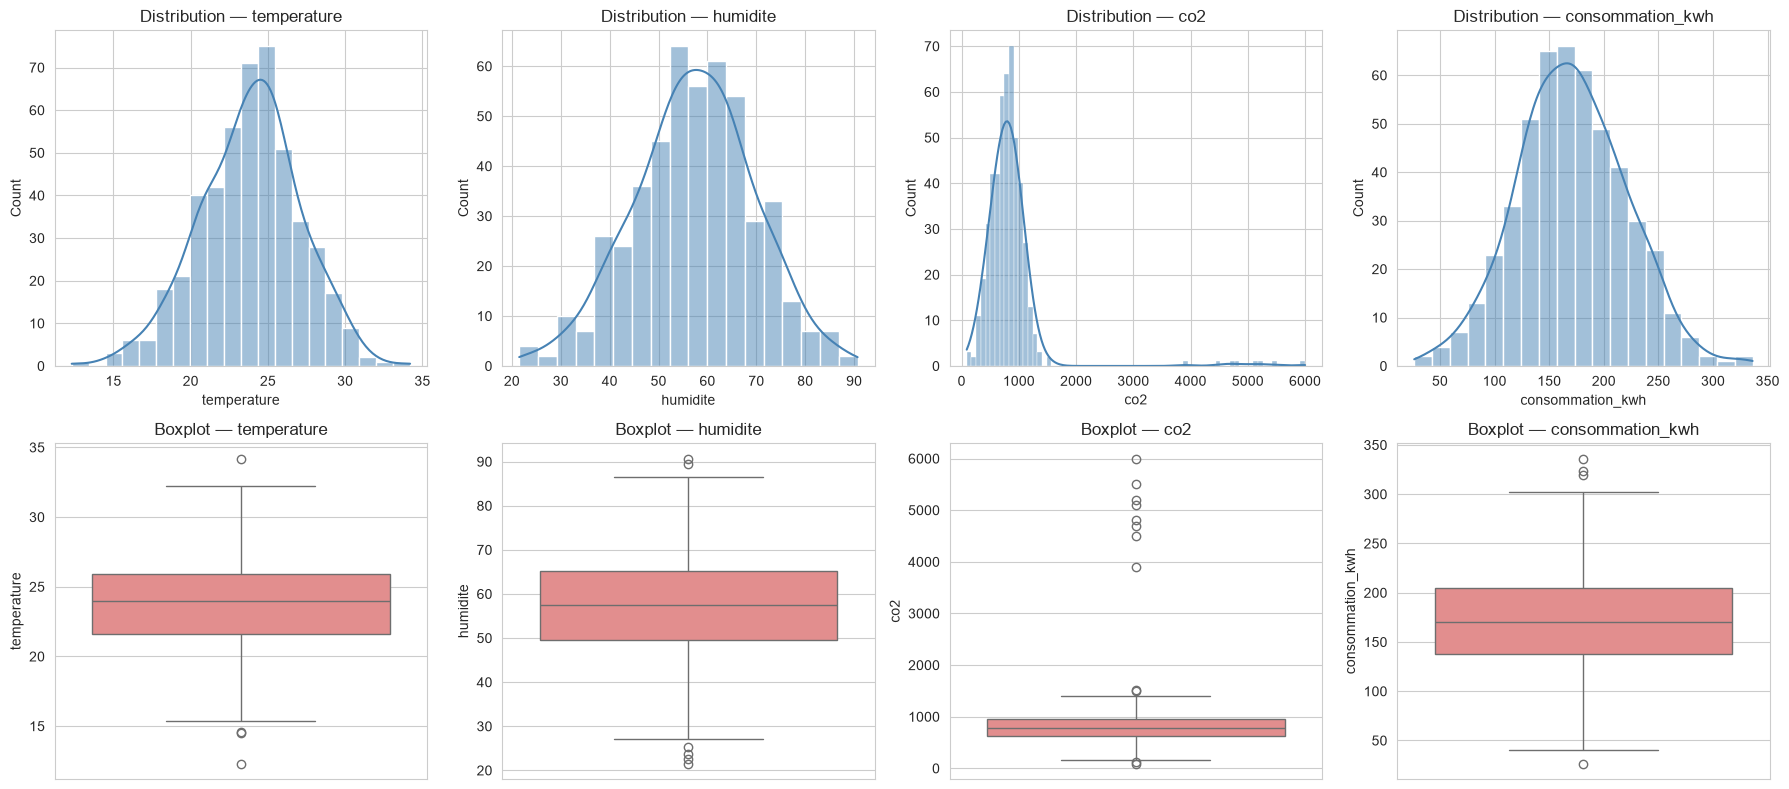

In [32]:
vars_a_visualiser = ["temperature", "humidite", "co2", "consommation_kwh"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(vars_a_visualiser):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0, i], color="steelblue")
    axes[0, i].set_title(f"Distribution — {col}")

    sns.boxplot(y=df[col].dropna(), ax=axes[1, i], color="lightcoral")
    axes[1, i].set_title(f"Boxplot — {col}")

plt.tight_layout()
plt.show()

**15.a** Les distributions (symétrique ou non) 

Les distributions (symétrique ou non).

- temperature : distribution plutôt symétrique, en cloche, centrée autour de 24°C.
- humidite : distribution relativement symétrique.
- co2 : distribution asymétrique à droite (étalée vers les valeurs élevées).
- consommation_kwh : distribution gl obalement symétrique, légèrement étalée.

**15.b** La dispersion 

Visible via l'écart-type (question 1.10) et la hauteur des boîtes des boxplots — `co2` a la plus grande dispersion relative, cohérent avec son écart-type élevé.


In [33]:
df[vars_a_visualiser].std().sort_values(ascending=False)

co2                 585.513736
consommation_kwh     49.828090
humidite             12.249550
temperature           3.266553
dtype: float64

**15.c** Les valeurs extrêmes 

Les boxplots font apparaître des points au-delà des moustaches, en particulier sur `co2` (valeurs proches de 6000 ppm) et consommation_kwh.

**15.d** les valeurs potentiellement aberrantes 

 Sur les boxplots, `co2` et `consommation_kwh` ont quelques points au-delà des moustaches — c'est là que se trouvent les valeurs potentiellement aberrantes. `temperature` et `humidite` n'en montrent presque pas.

<mark style= "background-color: lightblue">**📋Question 16**</mark>

**Quelle stratégie utiliser pour les valeurs aberrantes ?**

On repère les valeurs aberrantes avec la méthode IQR : une valeur est aberrante si elle sort de `[Q1 - 1.5×IQR ; Q3 + 1.5×IQR]`. La stratégie dépend ensuite de la cause : si la valeur est manifestement impossible, on la transforme en valeur manquante ; si elle est réelle mais extrême, on ne la supprime pas d'office — on cherche d'abord à comprendre son origine.

<mark style= "background-color: lightblue">**📋Question 17: Affichage des fréquences**</mark>

- **a. bâtiments**

In [34]:
df["batiment"].value_counts()

batiment
B1    92
B5    65
B7    64
B2    60
B4    58
B3    57
B8    53
B6    51
Name: count, dtype: int64

- **b.types de bâtiments**

In [35]:
df["type_batiment"].value_counts()

type_batiment
Bureau               211
Centre Commercial     65
École                 59
Hôpital               58
Entrepôt              53
Université            49
Ecole                  1
Name: count, dtype: int64